<a href="https://colab.research.google.com/github/joshtovar/MAT422/blob/main/MAT422_Section1_2_Linear_Algebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/joshtovar/MAT422/blob/main/MAT422_Section1_2_Linear_Algebra.ipynb)

# MAT 422 - Section 1.2: Linear Algebra Concepts in Python

**Topics:** linear spaces, orthogonality, Gram-Schmidt process, eigenvalues and eigenvectors

> Student note: This Colab badge is required for submission. Create or edit the notebook in Google Colab, then save it directly to GitHub so the badge/icon remains available for grading and reruns.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.2.1 Linear Spaces

A linear space is closed under vector addition and scalar multiplication. These vectors in R3 will still be in R3 after addition and scalar multiplication. Also, a linear combination of the two vectors will still be in the same space

In [ ]:
#Make vectors
u = np.array([4, 3, -2], dtype=float)
v = np.array([5, -1, 6], dtype=float)
c = 4

print("u =", u)
print("v =", v)
print("u + v =", u + v)
print("c * u =", c * u)
print("linear combination 4u + 3v =", 4*u + 3*v)
print("zero vector =", np.zeros_like(u))
print("additive inverse check u + (-u) =", u + (-u))

u = [ 4.  3. -2.]
v = [ 5. -1.  6.]
u + v = [9. 2. 4.]
c * u = [16. 12. -8.]
linear combination 4u + 3v = [31.  9. 10.]
zero vector = [0. 0. 0.]
additive inverse check u + (-u) = [0. 0. 0.]


Even after adding u and v, scaling u by c, or combining both, every result is still a 3-element vector — showing R3 stays closed under these operations.



---



A useful non-example is the set of vectors in R2 whose first coordinate is exactly 1. It is not a vector space because multiplying by most scalars leaves the set.

In [ ]:
w = np.array([1, 6], dtype=float)
scaled_w = 3 * w
print("w =", w)
print("3w =", scaled_w)
print("Is 2w still in the set first coordinate = 1?", np.isclose(scaled_w[0], 1))

w = [1. 6.]
3w = [ 3. 18.]
Is 2w still in the set first coordinate = 1? False


## 1.2.2 Orthogonality

Two vectors are always orthogonal when their dot product is zero. On a geometric scale, the angle between them is 90 degrees. The projection of one vector onto an orthogonal vector also has zero length.

a dot b = 0.0
angle in degrees = 90.0
projection of a onto b = [-0.  0.]


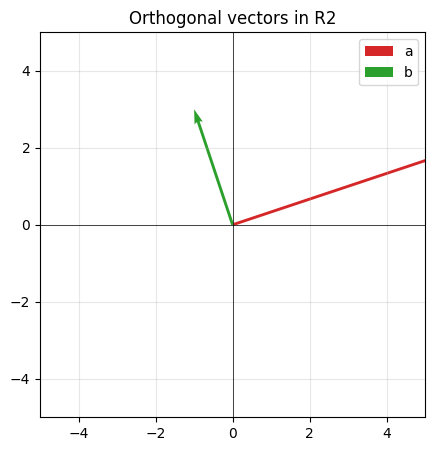

In [ ]:
a = np.array([6, 2], dtype=float)
b = np.array([-1, 3], dtype=float)

dot_ab = np.dot(a, b)
angle = np.degrees(np.arccos(dot_ab / (np.linalg.norm(a) * np.linalg.norm(b))))
projection_of_a_on_b = (np.dot(a, b) / np.dot(b, b)) * b

print("a dot b =", dot_ab)
print("angle in degrees =", angle)
print("projection of a onto b =", projection_of_a_on_b)

plt.figure(figsize=(5, 5))
plt.quiver(0, 0, a[0], a[1], angles="xy", scale_units="xy", scale=1, color="tab:red", label="a")
plt.quiver(0, 0, b[0], b[1], angles="xy", scale_units="xy", scale=1, color="tab:green", label="b")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.title("Orthogonal vectors in R2")
plt.show()

## 1.2.3 Gram-Schmidt Process

The Gram-Schmidt process converts a linearly independent set of vectors into an orthonormal basis for the same span. The loop below subtracts projections onto earlier basis vectors, then normalizes the remaining component.

In [ ]:
def gram_schmidt(columns):
    basis = []
    for x in columns.T:
        y = x.astype(float).copy()
        for q in basis:
            y -= np.dot(q, y) * q
        norm_y = np.linalg.norm(y)
        if norm_y < 1e-12:
            raise ValueError("Input vectors are linearly dependent or nearly dependent.")
        basis.append(y / norm_y)
    return np.column_stack(basis)

#Create A
A = np.array([
    [2, 1, 0],
    [1, 3, 1],
    [0, 1, 4],
], dtype=float)

#Compute Gram_Schmidt on A
Q = gram_schmidt(A)
print("Original column vectors A:")
print(A)
print("\nOrthonormal basis Q:")
print(Q)
print("\nQ.T @ Q should be the identity matrix:")
print(Q.T @ Q)
print("All close to identity?", np.allclose(Q.T @ Q, np.eye(3)))

Original column vectors A:
[[2. 1. 0.]
 [1. 3. 1.]
 [0. 1. 4.]]

Orthonormal basis Q:
[[ 0.8944 -0.4082  0.1826]
 [ 0.4472  0.8165 -0.3651]
 [ 0.      0.4082  0.9129]]

Q.T @ Q should be the identity matrix:
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
All close to identity? True


## 1.2.4 Eigenvalues and Eigenvectors

For a square matrix A, an eigenvector v keeps its direction when multiplied by A. Only its scale changes: `A v = lambda v`, where lambda is the eigenvalue.

In [ ]:
#Create M
M = np.array([
    [4, 6],
    [1, 4],
], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(M)
print("Matrix M:")
print(M)
print("eigenvalues =", eigenvalues)
print("eigenvectors as columns:")
print(eigenvectors)

#Grab Eigenpair's
for i, lam in enumerate(eigenvalues):
    vec = eigenvectors[:, i]
    residual = M @ vec - lam * vec
    print(f"\nEigenpair {i+1}")
    print("lambda =", lam)
    print("v =", vec)
    print("M @ v =", M @ vec)
    print("lambda * v =", lam * vec)
    print("residual norm =", np.linalg.norm(residual))
    print("dot product of eigenvectors =", np.dot(eigenvectors[:,0], eigenvectors[:,1]))

Matrix M:
[[4. 6.]
 [1. 4.]]
eigenvalues = [6.4495 1.5505]
eigenvectors as columns:
[[ 0.9258 -0.9258]
 [ 0.378   0.378 ]]

Eigenpair 1
lambda = 6.449489742783178
v = [0.9258 0.378 ]
M @ v = [5.9711 2.4377]
lambda * v = [5.9711 2.4377]
residual norm = 4.440892098500626e-16

Eigenpair 2
lambda = 1.5505102572168217
v = [-0.9258  0.378 ]
M @ v = [-1.4355  0.586 ]
lambda * v = [-1.4355  0.586 ]
residual norm = 4.577566798522237e-16


Note that M is not symmetric here, so the eigenvectors aren't necessarily orthogonal (unlike the Gram-Schmidt basis above). You can check this: the dot product of the two eigenvectors isn't zero.

## Reflection and Submission Checklist

* I explained each concept before showing the code.
* I checked my orthogonal vectors' dot product came out to 0, and Gram-Schmidt gave Q.T @ Q ≈ identity.
* I used my own vectors and matrices in every section, not the example's original numbers.
* I ran the whole notebook top to bottom with no errors.
* I saved this notebook directly from Colab to GitHub.